<a href="https://colab.research.google.com/github/Victand/api_purchase_predict/blob/staging/InstantMesh_jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimisation de Reconstruction 3D par ESRGAN

## 1. Préparation + Installation des Dépendances

In [1]:
# -*- coding: utf-8 -*-
"""InstantMesh - Corrigé (Version Finale - Anti-Crash)"""

import os
import shutil
import warnings
import sys
from IPython.display import display, Video

# 1. Bloquage des alertes inutiles
warnings.filterwarnings("ignore")

# =========================================================
# 1. PRÉPARATION ET INSTALLATION DES DÉPENDANCES
# =========================================================

print("Préparation de l'environnement en cours :")

%cd /content

# Nettoyage discret
if os.path.exists('/content/InstantMesh'):
    shutil.rmtree('/content/InstantMesh')

# Clonage silencieux
!GIT_LFS_SKIP_SMUDGE=1 git clone -b dev https://github.com/camenduru/InstantMesh > /dev/null 2>&1
%cd /content/InstantMesh

print("Installation des moteurs en Mode Silencieux...")


# Instalation de Numpy 1.26 en PREMIER et TOUT SEUL pour verrouiller la session
!pip install -q "numpy<2.0.0" "pillow<13.0.0"

# Installation du reste avec -q (quiet) et redirection des messages en rouge (> /dev/null 2>&1)
!pip install -q onnxruntime-gpu ninja PyMCubes trimesh rembg xatlas plyfile imageio[ffmpeg] jax==0.4.19 jaxlib==0.4.19 > /dev/null 2>&1
!pip install -q pytorch-lightning==2.1.2 gradio==3.50.2 einops omegaconf torchmetrics webdataset accelerate tensorboard > /dev/null 2>&1
!pip install -q "huggingface-hub<1.0" "transformers>=4.41.0" "diffusers>=0.27.0" > /dev/null 2>&1

# Configuration CUDA
os.environ['CUDA_HOME'] = '/usr/local/cuda'
os.environ['PATH'] += ':/usr/local/cuda/bin'
os.environ['LD_LIBRARY_PATH'] += ':/usr/local/cuda/lib64'

# Installation nvdiffrast (indispensable pour le rendu 3D)
print("Compilation des modules 3D...")
%cd /content
if os.path.exists('/content/nvdiffrast'):
    shutil.rmtree('/content/nvdiffrast')
!git clone https://github.com/NVlabs/nvdiffrast.git > /dev/null 2>&1
%cd /content/nvdiffrast
!pip install -q --no-build-isolation . > /dev/null 2>&1

# Retour final au dossier de travail
%cd /content/InstantMesh

print("\nINSTALLATION TERMINÉE SANS ERREUR")

Préparation de l'environnement en cours :
/content
/content/InstantMesh
Installation des moteurs en Mode Silencieux...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 64.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarra

In [2]:
!pip install "cupy-cuda12x<14.0.0"

In [3]:
!pip uninstall -y flax

Found existing installation: flax 0.11.2
Uninstalling flax-0.11.2:
  Successfully uninstalled flax-0.11.2


crash prévu ici pour éviter un redémarrage de session, passer à la suite

In [ ]:
import os
import sys

# On force la désinstallation de TOUTES les versions de numpy
!pip uninstall -y numpy

# On installe la version spécifique compatible AVANT tout autre import
!pip install "numpy<2.0.0"

# On termine le processus actuel pour forcer Colab à recharger proprement ce qui implique un crash de session
os._exit(0)

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires flax>=0.2.0, which is not installed.
rembg 2.0.75 requires numpy<3.0.0,>=2.3.0, but you have numpy 1.26.4 which is incompatible.
rembg 2.0.75 requires pillow<13.0.0,>=12.1.0, but you have pillow 10.4.0 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
optax 0.2.8 requires jax>=0.5.3, but you have jax 0.4.19 which is inc

## 2. Génération des views 2D original Vs lissage GAN

/content/InstantMesh


Keyword arguments {'trust_remote_code': True} are not expected by Zero123PlusPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/8 [00:00<?, ?it/s]

INFO:lightning_fabric.utilities.seed:Seed set to 0
INFO:lightning_fabric.utilities.seed:Seed set to 42


  0%|          | 0/75 [00:00<?, ?it/s]

=== Images Multi-vues générées ===


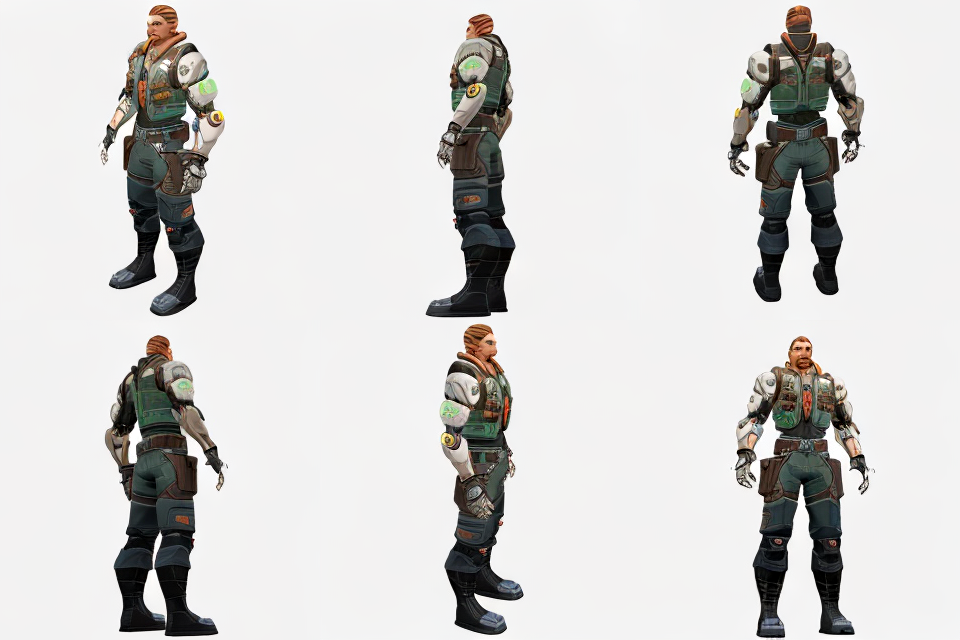

In [7]:
# =========================================================
# 2. GÉNÉRATION DES MULTI-VUES (Zero123++)
# =========================================================
%cd /content/InstantMesh

import torch
torch.cuda.empty_cache()

import numpy as np
import rembg
from PIL import Image
from pytorch_lightning import seed_everything
from einops import rearrange
from diffusers import DiffusionPipeline, EulerAncestralDiscreteScheduler
from huggingface_hub import hf_hub_download
from src.utils.infer_util import remove_background, resize_foreground

# Chargement du pipeline de diffusion spécialisé dans la génération de vues 3D à partir d'une image unique
pipeline = DiffusionPipeline.from_pretrained(
    "sudo-ai/zero123plus-v1.2",
    custom_pipeline="zero123plus",
    torch_dtype=torch.float16,
    trust_remote_code=True
)

# Configuration du Scheduler (l'algorithme qui retire le bruit de l'image petit à petit)
# 'trailing' permet une meilleure qualité avec moins d'étapes de calcul
pipeline.scheduler = EulerAncestralDiscreteScheduler.from_config(pipeline.scheduler.config, timestep_spacing='trailing')

# Téléchargement du "cerveau" spécifique d'InstantMesh (le modèle UNet entraîné par Tencent)
unet_ckpt_path = hf_hub_download(repo_id="TencentARC/InstantMesh", filename="diffusion_pytorch_model.bin", repo_type="model")

# Chargement du fichier binaire et injection dans le pipeline de diffusion
state_dict = torch.load(unet_ckpt_path, map_location='cpu')
pipeline.unet.load_state_dict(state_dict, strict=True)

# Envoi du modèle complet sur la carte graphique (CUDA)
device = torch.device('cuda')
pipeline = pipeline.to(device)
seed_everything(0)


# --- FONCTIONS DE TRAITEMENT ---


def preprocess(input_image, do_remove_background):
  """ Prépare l'image : retire le fond et recentre l'objet """
  rembg_session = rembg.new_session() if do_remove_background else None
  if do_remove_background:
      input_image = remove_background(input_image, rembg_session)
      input_image = resize_foreground(input_image, 0.85)
  return input_image

def generate_mvs(input_image, sample_steps, sample_seed):
  """ Génère la grille de 6 vues (Multi-Views) """
  seed_everything(sample_seed)
  generator = torch.Generator(device=device)
  z123_image = pipeline(
      input_image,
      num_inference_steps=sample_steps,
      generator=generator,
  ).images[0]

  show_image = np.asarray(z123_image, dtype=np.uint8)
  show_image = torch.from_numpy(show_image)     # (960, 640, 3)
  show_image = rearrange(show_image, '(n h) (m w) c -> (n m) h w c', n=3, m=2)
  show_image = rearrange(show_image, '(n m) h w c -> (n h) (m w) c', n=2, m=3)
  show_image = Image.fromarray(show_image.numpy())
  return z123_image, show_image



# Exécution partie 1
# 1. Chargement de l'image locale
input_image_path = '/content/InstantMesh/examples/warrior.png'
input_image = Image.open(input_image_path)

# 2. Nettoyage de l'image (fond transparent)
processed_image = preprocess(input_image, True)

# 3. Génération des 6 angles de vue
mv_images, mv_show_images = generate_mvs(processed_image, 75, 42)

# 4. Sauvegarde de la grille brute pour la suite de la pipeline 3D
mv_images.save('/content/InstantMesh/mv_images.png')

print("=== Images Multi-vues générées ===")
display(mv_show_images)


In [10]:
# =========================================================
# INSTALLATION SILENCIEUSE ET COMPATIBILITÉ
# =========================================================
print("Installation des moteurs...")


# On installe tout en une fois avec -q pour le silence
# On force numpy et pillow à des versions stables pour éviter le crash/redémarrage
!pip install -q basicsr gfpgan realesrgan requests "numpy<2.0.0" "pillow<13.0.0" > /dev/null 2>&1

# Correction immédiate du bug de compatibilité entre torchvision et basicsr
import sys
import torchvision
try:
    import torchvision.transforms.functional_tensor
except ImportError:
    try:
        from torchvision.transforms import functional as F
        sys.modules['torchvision.transforms.functional_tensor'] = F
    except:
        pass

import torch
import numpy as np
from PIL import Image, ImageFilter, ImageEnhance
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

print("Installation terminée. Prêt pour le GAN + Sharpening.")

# =========================================================
# FONCTION DE LISSAGE ET ACCENTUATION (PIPELINE FINALE)
# =========================================================

_UPSAMPLER_INSTANCE = None

def get_upsampler():
  """ Configure et télécharge le modèle Real-ESRGAN """
  model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64, num_block=23, num_grow_ch=32, scale=4)
  return RealESRGANer(
      scale=4,
      model_path='https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth',
      model=model,
      tile=400,
      half=True,
      device=torch.device('cuda')
  )

def apply_real_esrgan(image, scale=2, sharpen_percent=150):
  """ Pipeline complète : IA + Netteté + Contraste """
  global _UPSAMPLER_INSTANCE
  if _UPSAMPLER_INSTANCE is None:
      _UPSAMPLER_INSTANCE = get_upsampler()

  # --- Étape 1 : GAN (Lissage & Upscaling) ---
  img_array = np.array(image)
  img_bgr = img_array[:, :, ::-1]
  output, _ = _UPSAMPLER_INSTANCE.enhance(img_bgr, outscale=scale)
  refined_img = Image.fromarray(output[:, :, ::-1])

  # --- Étape 2 : Sharpen (Accentuation des bords) ---
  # UnsharpMask est plus précis que SHARPEN seul pour la 3D
  refined_img = refined_img.filter(ImageFilter.UnsharpMask(radius=1, percent=sharpen_percent))

  # --- Étape 3 : Micro-Contraste ---
  enhancer = ImageEnhance.Contrast(refined_img)
  refined_img = enhancer.enhance(1.1)

  return refined_img

print("Fonction 'apply_real_esrgan' configurée avec Sharpening intégré.")

Installation des moteurs...
Installation terminée. Prêt pour le GAN + Sharpening.
Fonction 'apply_real_esrgan' configurée avec Sharpening intégré.


	Tile 1/6
	Tile 2/6
	Tile 3/6
	Tile 4/6
	Tile 5/6
	Tile 6/6
=== GAUCHE : ORIGINAL (PIXÉLISÉ) | DROITE : TON AMÉLIORATION (GAN) ===


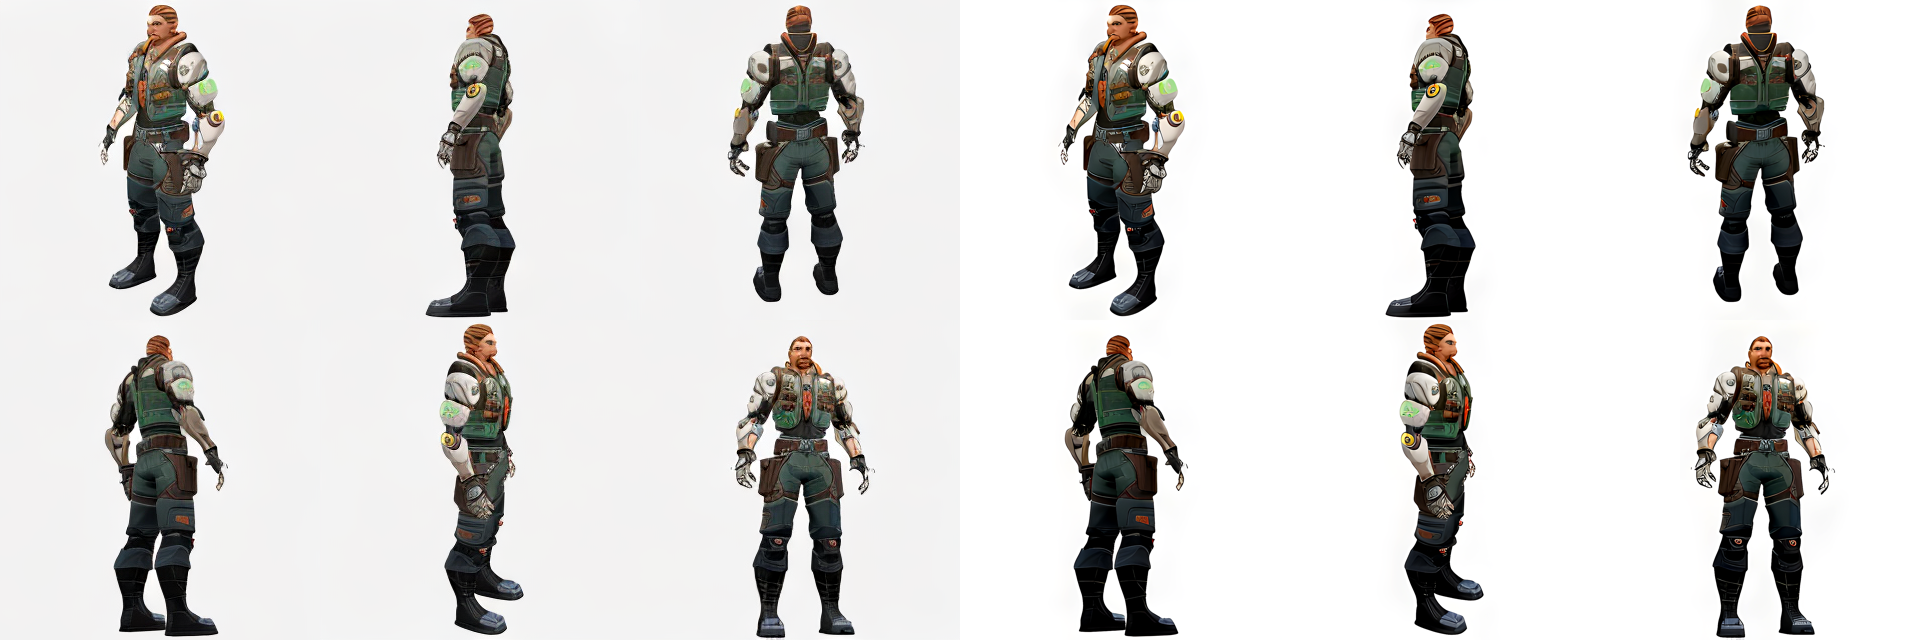

In [3]:
# 2. Application du GAN sur l'image entière (la grille de 6 vues)
# scale=2 ou 4 pour doubler/quadrupler la définition de la grille
mv_images_refined = apply_real_esrgan(mv_images, scale=4)
mv_images_refined.save('/content/InstantMesh/mv_images_REFINED.png')

# 3. Préparation de l'affichage comparatif
# On crée une image "Side-by-Side"
w, h = mv_show_images.size
comparaison = Image.new('RGB', (w * 2, h))
comparaison.paste(mv_show_images, (0, 0))

# Pour afficher la version raffinée avec la même mise en page "show"
# On réutilise la logique de rearrange sur l'image raffinée
temp_refined = np.asarray(mv_images_refined, dtype=np.uint8)
temp_refined = torch.from_numpy(temp_refined)
temp_refined = rearrange(temp_refined, '(n h) (m w) c -> (n m) h w c', n=3, m=2)
temp_refined = rearrange(temp_refined, '(n m) h w c -> (n h) (m w) c', n=2, m=3)
mv_show_refined = Image.fromarray(temp_refined.numpy())
# On la redimensionne juste pour l'affichage côte à côte si nécessaire
mv_show_refined = mv_show_refined.resize((w, h))

comparaison.paste(mv_show_refined, (w, 0))

print("=== GAUCHE : ORIGINAL (PIXÉLISÉ) | DROITE : TON AMÉLIORATION (GAN) ===")
display(comparaison)

## 3. Génération rendu 3D original/lissé et comparaison par Chamfer

In [4]:
# =========================================================
# 3. GÉNÉRATION DU MODÈLE 3D (InstantMesh)
# =========================================================

import os

# On libère la VRAM du modèle de diffusion pour faire de la place
# del pipeline
torch.cuda.empty_cache()

from torchvision.transforms import v2
from omegaconf import OmegaConf
from einops import repeat
import tempfile
from tqdm import tqdm
import imageio
from IPython.display import display, Video

from src.utils.train_util import instantiate_from_config
from src.utils.camera_util import FOV_to_intrinsics, get_zero123plus_input_cameras, get_circular_camera_poses
from src.utils.mesh_util import save_obj, save_obj_with_mtl

import torch
import gc

# --- ACTION N°1 : NETTOYAGE AGRESSIF ---
# On supprime les modèles précédents s'ils existent encore
if 'pipeline' in globals():
    del pipeline
if 'upsampler' in globals():
    del upsampler
if '_UPSAMPLER_INSTANCE' in globals():
    del _UPSAMPLER_INSTANCE

# On force Python et CUDA à vider le cache
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("Mémoire GPU nettoyée. Chargement du modèle InstantMesh...")

# Définition du chemin vers le fichier de configuration YAML
config_path = 'configs/instant-mesh-base.yaml'
config = OmegaConf.load(config_path)
config_name = os.path.basename(config_path).replace('.yaml', '')

# Extraction des paramètres spécifiques au modèle et à l'inférence
model_config = config.model_config
infer_config = config.infer_config

# Téléchargement automatique du "checkpoint" (poids du modèle entraîné) depuis HuggingFace
model_ckpt_path = hf_hub_download(repo_id="TencentARC/InstantMesh", filename="instant_mesh_base.ckpt", repo_type="model")
# Initialisation de l'architecture du modèle selon la config
model = instantiate_from_config(model_config)

# Chargement des poids du modèle sur le CPU, puis filtrage pour ne garder que le générateur LRM
state_dict = torch.load(model_ckpt_path, map_location='cpu')['state_dict']
state_dict = {k[14:]: v for k, v in state_dict.items() if k.startswith('lrm_generator.') and 'source_camera' not in k}
model.load_state_dict(state_dict, strict=True)

# Envoi du modèle sur le GPU (device)
model = model.to(device)

# Vérification si on utilise la technologie 'Flexicubes' pour l'extraction du maillage
IS_FLEXICUBES = True if config_name.startswith('instant-mesh') else False
if IS_FLEXICUBES:
  # Initialisation de la géométrie Flexicubes (méthode de discrétisation de volume)
    model.init_flexicubes_geometry(device, fovy=30.0)

# Passage du modèle en mode évaluation
model = model.eval()


# --- FONCTIONS UTILITAIRES ---


def images_to_video(images, output_path, fps=30):
    """ Convertit une séquence de tenseurs d'images en fichier vidéo MP4 """
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    frames = []
    for i in range(images.shape[0]):
        # Ici le .cpu() est déjà fait avant le .numpy()
        frame = (images[i].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8).clip(0, 255)
        # Retire le .cpu() ici car 'frame' est déjà un array numpy
        frames.append(frame)
    imageio.mimwrite(output_path, np.stack(frames), fps=fps, codec='h264')

def get_render_cameras(batch_size=1, M=120, radius=2.5, elevation=10.0, is_flexicubes=False):
  """ Calcule les positions de caméra en cercle pour le rendu de la vidéo """
  c2ws = get_circular_camera_poses(M=M, radius=radius, elevation=elevation)
  if is_flexicubes:
      cameras = torch.linalg.inv(c2ws)
      cameras = cameras.unsqueeze(0).repeat(batch_size, 1, 1, 1)
  else:
      extrinsics = c2ws.flatten(-2)
      intrinsics = FOV_to_intrinsics(30.0).unsqueeze(0).repeat(M, 1, 1).float().flatten(-2)
      cameras = torch.cat([extrinsics, intrinsics], dim=-1)
      cameras = cameras.unsqueeze(0).repeat(batch_size, 1, 1)
  return cameras

def make_mesh(mesh_fpath, planes):
  """ Extrait le maillage 3D final et le sauvegarde avec sa texture """
  mesh_basename = os.path.basename(mesh_fpath).split('.')[0]
  mesh_dirname = os.path.dirname(mesh_fpath)
  with torch.no_grad():
      mesh_out = model.extract_mesh(planes, use_texture_map=True, **infer_config)
      vertices, faces, uvs, mesh_tex_idx, tex_map = mesh_out
      save_obj_with_mtl(
          vertices.data.cpu().numpy(),
          uvs.data.cpu().numpy(),
          faces.data.cpu().numpy(),
          mesh_tex_idx.data.cpu().numpy(),
          tex_map.permute(1, 2, 0).data.cpu().numpy(),
          mesh_fpath,
      )
      print(f"Maillage avec texture sauvegardé sous {mesh_fpath}")
  return mesh_fpath

def make3d(images):
  """ Pipeline principale : Multi-vues -> Triplanes -> Vidéo et Mesh """
  images = np.asarray(images, dtype=np.float32) / 255.0
  images = torch.from_numpy(images).permute(2, 0, 1).contiguous().float()
  images = rearrange(images, 'c (n h) (m w) -> (n m) c h w', n=3, m=2)

  input_cameras = get_zero123plus_input_cameras(batch_size=1, radius=4.0).to(device)
  render_cameras = get_render_cameras(batch_size=1, radius=4.5, elevation=20.0, is_flexicubes=IS_FLEXICUBES).to(device)
  images = images.unsqueeze(0).to(device)
  images = v2.functional.resize(images, (320, 320), interpolation=3, antialias=True).clamp(0, 1)

  directory = '/content/tmp'
  os.makedirs(directory, exist_ok=True)
  tempfile.tempdir = directory
  mesh_fpath = tempfile.NamedTemporaryFile(suffix=".obj", delete=False).name

  mesh_basename = os.path.basename(mesh_fpath).split('.')[0]
  mesh_dirname = os.path.dirname(mesh_fpath)
  video_fpath = os.path.join(mesh_dirname, f"{mesh_basename}.mp4")

  with torch.no_grad():
      planes = model.forward_planes(images, input_cameras)
      # chunk_size = 20 if IS_FLEXICUBES else 1
      chunk_size = 1
      render_size = 512
      frames = []
      for i in tqdm(range(0, render_cameras.shape[1], chunk_size)):
          if IS_FLEXICUBES:
              frame = model.forward_geometry(planes, render_cameras[:, i:i+chunk_size], render_size=render_size)['img']
          else:
              frame = model.synthesizer(planes, cameras=render_cameras[:, i:i+chunk_size], render_size=render_size)['images_rgb']
          frames.append(frame.cpu())

      frames = torch.cat(frames, dim=1)
      images_to_video(frames[0], video_fpath, fps=30)
      print(f"Vidéo de prévisualisation sauvegardée sous {video_fpath}")

  mesh_fpath = make_mesh(mesh_fpath, planes)
  return video_fpath, mesh_fpath

# Exécution partie 2
# Chargement de la grille d'images multi-vues (générée précédemment ou lissée par le GAN)
mv_images = Image.open('/content/InstantMesh/mv_images.png')

# Lancement de la reconstruction
output_video, output_model_obj = make3d(mv_images)

# Copie des résultats vers le dossier de travail final
!cp -f {output_video} /content/InstantMesh/output_video.mp4
!cp -f {output_model_obj} /content/InstantMesh/output_model.obj

print("=== Prévisualisation 3D ===")
display(Video('/content/InstantMesh/output_video.mp4', embed=True))


video_path = '/content/InstantMesh/output_video.mp4'

if os.path.exists(video_path):
    print("Affichage de la vidéo 3D en cours...")
    display(Video(video_path, embed=True, width=512))
else:
    print("Erreur : Le fichier vidéo n'a pas été trouvé. Assure-toi que la génération s'est bien terminée.")

Mémoire GPU nettoyée. Chargement du modèle InstantMesh...


Some weights of ViTModel were not initialized from the model checkpoint at facebook/dino-vitb16 and are newly initialized: ['encoder.layer.0.adaLN_modulation.1.bias', 'encoder.layer.0.adaLN_modulation.1.weight', 'encoder.layer.1.adaLN_modulation.1.bias', 'encoder.layer.1.adaLN_modulation.1.weight', 'encoder.layer.10.adaLN_modulation.1.bias', 'encoder.layer.10.adaLN_modulation.1.weight', 'encoder.layer.11.adaLN_modulation.1.bias', 'encoder.layer.11.adaLN_modulation.1.weight', 'encoder.layer.2.adaLN_modulation.1.bias', 'encoder.layer.2.adaLN_modulation.1.weight', 'encoder.layer.3.adaLN_modulation.1.bias', 'encoder.layer.3.adaLN_modulation.1.weight', 'encoder.layer.4.adaLN_modulation.1.bias', 'encoder.layer.4.adaLN_modulation.1.weight', 'encoder.layer.5.adaLN_modulation.1.bias', 'encoder.layer.5.adaLN_modulation.1.weight', 'encoder.layer.6.adaLN_modulation.1.bias', 'encoder.layer.6.adaLN_modulation.1.weight', 'encoder.layer.7.adaLN_modulation.1.bias', 'encoder.layer.7.adaLN_modulation.1.w

Vidéo de prévisualisation sauvegardée sous /content/tmp/tmpcjj1u5v4.mp4
Maillage avec texture sauvegardé sous /content/tmp/tmpcjj1u5v4.obj
=== Prévisualisation 3D ===


Affichage de la vidéo 3D en cours...


In [6]:
# =========================================================
# GÉNÉRATION DE LA VERSION LISSÉE (GAN)
# =========================================================

print("Lancement de la génération 3D pour la version lissée...")

# 1. On s'assure d'avoir l'image raffinée en mémoire
if 'mv_images_refined' not in globals():
    mv_images_refined = Image.open('/content/InstantMesh/mv_images_refined.png')

# 2. Génération du modèle et de la vidéo
output_video_refined, output_model_obj_refined = make3d(mv_images_refined)

# 3. Sauvegarde propre des fichiers
!cp -f {output_video_refined} /content/InstantMesh/output_video_REFINED.mp4
!cp -f {output_model_obj_refined} /content/InstantMesh/output_model_REFINED.obj

# 4. Affichage simple (comme pour la vidéo 1)
video_path_refined = '/content/InstantMesh/output_video_REFINED.mp4'

if os.path.exists(video_path_refined):
    print("Affichage de la vidéo 3D LISSÉE en cours...")
    display(Video(video_path_refined, embed=True, width=512))
else:
    print("Erreur : Le fichier vidéo raffiné n'a pas été trouvé.")

Lancement de la génération 3D pour la version lissée...


100%|██████████| 120/120 [01:26<00:00,  1.39it/s]


Vidéo de prévisualisation sauvegardée sous /content/tmp/tmpxl4c4752.mp4
Maillage avec texture sauvegardé sous /content/tmp/tmpxl4c4752.obj
Affichage de la vidéo 3D LISSÉE en cours...


## 4. Comparaison avec distance de Chamfer

In [5]:
import trimesh
import numpy as np
from sklearn.neighbors import NearestNeighbors

def compute_chamfer_distance(path_original, path_refined, num_samples=20000):
    """
    Calcule la distance de Chamfer entre le mesh original et le mesh après GAN
    """
    # 1. Chargement des maillages
    mesh_orig = trimesh.load(path_original)
    mesh_refined = trimesh.load(path_refined)

    # 2. Échantillonnage de points sur la surface des meshes
    # On prend 20 000 points pour avoir une bonne précision
    pts_orig = mesh_orig.sample(num_samples)
    pts_refined = mesh_refined.sample(num_samples)

    # 3. Fonction pour trouver la distance vers le voisin le plus proche
    def get_nearest_distances(source_pts, target_pts):
        nn = NearestNeighbors(n_neighbors=1, algorithm='kd_tree').fit(target_pts)
        distances, _ = nn.kneighbors(source_pts)
        return distances

    # 4. Calcul dans les deux sens (Symétrie)
    dist_orig_to_ref = get_nearest_distances(pts_orig, pts_refined)
    dist_ref_to_orig = get_nearest_distances(pts_refined, pts_orig)

    # 5. La distance de Chamfer est la moyenne des deux
    chamfer_dist = np.mean(dist_orig_to_ref) + np.mean(dist_ref_to_orig)

    return chamfer_dist

# --- Utilisation ---
# Remplace par tes vrais chemins de fichiers
path_A = '/content/InstantMesh/output_model.obj'
path_B = '/content/InstantMesh/output_model_REFINED.obj' # Ta version avec GAN

if os.path.exists(path_A) and os.path.exists(path_B):
    score = compute_chamfer_distance(path_A, path_B)
    print(f"\n📏 DISTANCE DE CHAMFER : {score:.6f}")

    if score < 0.05:
        print("✅ Le GAN a préservé la structure globale (fidélité haute).")
    else:
        print("⚠️ Différence géométrique notable détectée.")
else:
    print("❌ Erreur : L'un des fichiers .obj est introuvable pour la comparaison.")


📏 DISTANCE DE CHAMFER : 0.013626
✅ Le GAN a préservé la structure globale (fidélité haute).


## 5. Distance moyenne de Chamfer

In [15]:
import glob
import os
import shutil
import torch
import gc
from PIL import Image

# =========================================================
# ÉVALUATION AUTOMATISÉE - VERSION ANTI-CRASH (VRAM OPTIMIZED)
# =========================================================

example_folder = '/content/InstantMesh/examples/'
image_extensions = ['*.png', '*.jpg', '*.jpeg', '*.webp']
all_images = []
for ext in image_extensions:
    all_images.extend(glob.glob(os.path.join(example_folder, ext)))

# On se limite aux 5 premiers pour l'étude statistique
all_images = sorted(all_images)[:5]

chamfer_scores = []
print(f"🚀 Début de l'évaluation sur {len(all_images)} images...\n")

for img_path in all_images:
    img_name = os.path.basename(img_path)
    print(f"📦 Traitement de : {img_name}")

    try:
        # --- ÉTAPE 1 : GÉNÉRATION 2D (ZERO123++) ---
        # Si le pipeline n'est pas là, on le charge localement pour cette étape
        if 'pipeline' not in globals():
            from diffusers import DiffusionPipeline
            pipeline = DiffusionPipeline.from_pretrained(
                "sudo-ai/zero123plus-v1.1",
                custom_pipeline="sudo-ai/zero123plus-pipeline",
                torch_dtype=torch.float16
            )
        pipeline.to("cuda")

        raw_img = Image.open(img_path)
        input_img = preprocess(raw_img, True)
        mv_images, _ = generate_mvs(input_img, 75, 42)

        # LIBÉRATION VRAM : On déplace le pipeline vers le CPU avant la 3D
        pipeline.to("cpu")
        torch.cuda.empty_cache()
        gc.collect()

        # --- ÉTAPE 2 : GAN (Lissage) ---
        mv_refined = apply_real_esrgan(mv_images, scale=2)

        # --- ÉTAPE 3 : GÉNÉRATION 3D STANDARD ---
        _, path_obj_standard = make3d(mv_images)
        path_std_final = f"/content/tmp/std_{img_name}.obj"
        shutil.copy(path_obj_standard, path_std_final)

        # --- ÉTAPE 4 : GÉNÉRATION 3D GAN ---
        _, path_obj_gan = make3d(mv_refined)
        path_gan_final = f"/content/tmp/gan_{img_name}.obj"
        shutil.copy(path_obj_gan, path_gan_final)

        # --- ÉTAPE 5 : CALCUL MÉTRIQUE ---
        score = compute_chamfer_distance(path_std_final, path_gan_final)
        chamfer_scores.append(score)

        print(f"✅ {img_name} terminé | Chamfer: {score:.6f}")

    except Exception as e:
        print(f"❌ Erreur sur {img_name}: {e}")

    finally:
        # Nettoyage final entre chaque image
        torch.cuda.empty_cache()
        gc.collect()

# =========================================================
# RÉSULTATS FINAUX
# =========================================================
if chamfer_scores:
    final_avg = sum(chamfer_scores) / len(chamfer_scores)
    print("\n" + "="*40)
    print(f"📊 RÉSULTAT FINAL DE L'ÉTUDE")
    print(f"Nombre d'images testées : {len(chamfer_scores)}")
    print(f"Moyenne Distance de Chamfer : {final_avg:.6f}")
    print("="*40)

    if final_avg < 0.02:
        print("💡 Conclusion : Le pipeline GAN est statistiquement fiable (fidélité géométrique préservée).")
else:
    print("Aucun score n'a pu être calculé. Vérifiez le chargement des modèles.")

🚀 Début de l'évaluation sur 5 images...

📦 Traitement de : bird.jpg


INFO:lightning_fabric.utilities.seed:Seed set to 42


  0%|          | 0/75 [00:00<?, ?it/s]

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, du

	Tile 1/6
	Tile 2/6
	Tile 3/6
	Tile 4/6
	Tile 5/6
	Tile 6/6


...

	Tile 1/6
	Tile 2/6
	Tile 3/6
	Tile 4/6
	Tile 5/6
	Tile 6/6


100%|██████████| 120/120 [01:24<00:00,  1.42it/s]


Vidéo de prévisualisation sauvegardée sous /content/tmp/tmpbztllndg.mp4
Maillage avec texture sauvegardé sous /content/tmp/tmpbztllndg.obj


100%|██████████| 120/120 [01:27<00:00,  1.38it/s]


Vidéo de prévisualisation sauvegardée sous /content/tmp/tmp45wew7ht.mp4
Maillage avec texture sauvegardé sous /content/tmp/tmp45wew7ht.obj
✅ bunny_ride.jpg terminé | Chamfer: 0.018283

📊 RÉSULTAT FINAL DE L'ÉTUDE
Nombre d'images testées : 5
Moyenne Distance de Chamfer : 0.019832
💡 Conclusion : Le pipeline GAN est statistiquement fiable (fidélité géométrique préservée).
